# LangGraph Subgraphs — Shared State Schema

This notebook demonstrates the **shared-schema** pattern for LangGraph subgraphs:
the child graph (`subgraph`) is built directly on the *same* `ParentState`
`TypedDict` that the parent graph uses, so the compiled subgraph can be added
straight into the parent graph as a node — no state-translation wrapper needed.

Flow: `question` → generate an English answer → translate it to Hindi.

**Models (local, via [Ollama](https://ollama.com), no API key required):**
- `llama3.2:3b` — small, fast local model used to generate the initial English answer.
- `gpt-oss:120b-cloud` — larger model (run through Ollama's cloud inference) used for the Hindi translation, where quality matters more.

**Prerequisites:**
1. [Ollama](https://ollama.com) installed and running.
2. Models pulled/available: `ollama pull llama3.2:3b` and `ollama pull gpt-oss:120b-cloud` (the `-cloud` model needs `ollama signin` once, since it runs on Ollama's cloud rather than your machine).
3. Run this notebook using the project's `.venv` kernel (it already has `langchain-ollama`, `langgraph`, etc. installed).

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama

In [2]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

## Shared state

`ParentState` is used by **both** the parent graph and the subgraph. Because
the schemas are identical, the compiled subgraph can be added directly as a
node in the parent graph — LangGraph just passes the state straight through.

In [3]:
parent_llm = ChatOllama(model='llama3.2:3b')
subgraph_llm = ChatOllama(model='gpt-oss:120b-cloud')

`parent_llm` (fast, local `llama3.2:3b`) drafts the English answer; `subgraph_llm`
(the bigger `gpt-oss:120b-cloud`) handles the Hindi translation, since
translation quality benefits more from a larger model than the initial draft
does.

In [4]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

**Subgraph node** — reads `answer_eng` from the shared state and writes
`answer_hin` back into it.

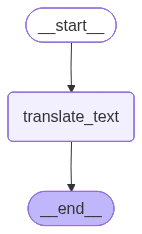

In [5]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

subgraph

**Build & compile the subgraph** on `ParentState` — a single `translate_text`
node from `START` to `END`.

In [6]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

**Parent node** — generates the English answer for the incoming `question`.

In [7]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

**Build the parent graph.** The compiled `subgraph` is added directly as the
`translate` node — this only works because it shares `ParentState` with the
parent graph.

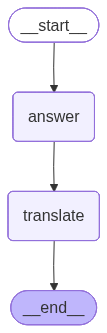

In [8]:
graph = parent_builder.compile()

graph

Compile the parent graph and (in a notebook with Mermaid/graphviz support)
render it.

In [9]:
graph.invoke({'question': 'What is Agentic AI in simple terms?'})

{'question': 'What is Agentic AI in simple terms?',
 'answer_eng': "In simple terms, Agentic AI refers to Artificial Intelligence that can make decisions and take actions based on its own goals and motivations, rather than just following instructions or reacting to external stimuli.\n\nThink of it like an autonomous car - it's not just a machine that follows the rules, but one that can adapt, learn, and even make choices on its own, such as taking a detour or changing its route.",
 'answer_hin': 'साधारण शब्दों में, एजेंटिक एआई का मतलब ऐसी कृत्रिम बुद्धिमत्ता से है जो अपने स्वयं के लक्ष्य और प्रेरणाओं के आधार पर निर्णय लेती है और कार्य करती है, न कि केवल निर्देशों का पालन करती है या बाहरी उत्तेजनाओं पर प्रतिक्रिया देती है।\n\nइसे एक स्वायत्त कार के रूप में सोचें—यह सिर्फ नियमों का पालन करने वाला उपकरण नहीं है, बल्कि ऐसा साधन है जो अनुकूलित हो सकता है, सीख सकता है, और अपनी ही पसंद से निर्णय ले सकता है, जैसे नया मार्ग चुनना या रास्ता बदलना।'}

Run the whole graph end-to-end: ask a question in English, get back both the
English answer and its Hindi translation.